In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
test = pd.read_json('/kaggle/input/pii-detection-removal-from-educational-data/test.json')
test.head

<bound method NDFrame.head of    document                                          full_text  \
0         7  Design Thinking for innovation reflexion-Avril...   
1        10  Diego Estrada\n\nDesign Thinking Assignment\n\...   
2        16  Reporting process\n\nby Gilberto Gamboa\n\nCha...   
3        20  Design Thinking for Innovation\n\nSindy Samaca...   
4        56  Assignment:  Visualization Reflection  Submitt...   
5        86  Cheese Startup - Learning Launch ​by Eladio Am...   
6        93  Silvia Villalobos\n\nChallenge:\n\nThere is a ...   
7       104  Storytelling  The Path to Innovation\n\nDr Sak...   
8       112  Reflection – Learning Launch\n\nFrancisco Ferr...   
9       123  Gandhi Institute of Technology and Management ...   

                                              tokens  \
0  [Design, Thinking, for, innovation, reflexion,...   
1  [Diego, Estrada, \n\n, Design, Thinking, Assig...   
2  [Reporting, process, \n\n, by, Gilberto, Gambo...   
3  [Design, Thinkin

In [5]:
train = pd.read_json('/kaggle/input/pii-detection-removal-from-educational-data/train.json')
train.head() 

,document,full_text,tokens,trailing_whitespace,labels
0,7,Design Thinking for innovation reflexion-Avril...,"[Design, Thinking, for, innovation, reflexion,...","[True, True, True, True, False, False, True, F...","[O, O, O, O, O, O, O, O, O, B-NAME_STUDENT, I-..."
1,10,Diego Estrada\n\nDesign Thinking Assignment\n\...,"[Diego, Estrada, \n\n, Design, Thinking, Assig...","[True, False, False, True, True, False, False,...","[B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O, O..."
2,16,Reporting process\n\nby Gilberto Gamboa\n\nCha...,"[Reporting, process, \n\n, by, Gilberto, Gambo...","[True, False, False, True, True, False, False,...","[O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O..."
3,20,Design Thinking for Innovation\n\nSindy Samaca...,"[Design, Thinking, for, Innovation, \n\n, Sind...","[True, True, True, False, False, True, False, ...","[O, O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT..."
4,56,Assignment: Visualization Reflection Submitt...,"[Assignment, :, , Visualization, , Reflecti...","[False, False, False, False, False, False, Fal...","[O, O, O, O, O, O, O, O, O, O, O, O, B-NAME_ST..."


In [6]:
combined = pd.concat([train,test])
combined.head()

,document,full_text,tokens,trailing_whitespace,labels
0,7,Design Thinking for innovation reflexion-Avril...,"[Design, Thinking, for, innovation, reflexion,...","[True, True, True, True, False, False, True, F...","[O, O, O, O, O, O, O, O, O, B-NAME_STUDENT, I-..."
1,10,Diego Estrada\n\nDesign Thinking Assignment\n\...,"[Diego, Estrada, \n\n, Design, Thinking, Assig...","[True, False, False, True, True, False, False,...","[B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O, O..."
2,16,Reporting process\n\nby Gilberto Gamboa\n\nCha...,"[Reporting, process, \n\n, by, Gilberto, Gambo...","[True, False, False, True, True, False, False,...","[O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O..."
3,20,Design Thinking for Innovation\n\nSindy Samaca...,"[Design, Thinking, for, Innovation, \n\n, Sind...","[True, True, True, False, False, True, False, ...","[O, O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT..."
4,56,Assignment: Visualization Reflection Submitt...,"[Assignment, :, , Visualization, , Reflecti...","[False, False, False, False, False, False, Fal...","[O, O, O, O, O, O, O, O, O, O, O, O, B-NAME_ST..."


In [7]:
combined.info

<bound method DataFrame.info of     document                                          full_text  \
0          7  Design Thinking for innovation reflexion-Avril...   
1         10  Diego Estrada\n\nDesign Thinking Assignment\n\...   
2         16  Reporting process\n\nby Gilberto Gamboa\n\nCha...   
3         20  Design Thinking for Innovation\n\nSindy Samaca...   
4         56  Assignment:  Visualization Reflection  Submitt...   
..       ...                                                ...   
5         86  Cheese Startup - Learning Launch ​by Eladio Am...   
6         93  Silvia Villalobos\n\nChallenge:\n\nThere is a ...   
7        104  Storytelling  The Path to Innovation\n\nDr Sak...   
8        112  Reflection – Learning Launch\n\nFrancisco Ferr...   
9        123  Gandhi Institute of Technology and Management ...   

                                               tokens  \
0   [Design, Thinking, for, innovation, reflexion,...   
1   [Diego, Estrada, \n\n, Design, Thinking, Assi

In [8]:
combined.dtypes

document                int64
full_text              object
tokens                 object
trailing_whitespace    object
labels                 object
dtype: object

In [10]:
combined.columns

Index(['document', 'full_text', 'tokens', 'trailing_whitespace', 'labels'], dtype='object')

In [11]:
combined.isnull().sum()/len(combined*100)

document               0.000000
full_text              0.000000
tokens                 0.000000
trailing_whitespace    0.000000
labels                 0.001467
dtype: float64

In [13]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
document,6817.0,14718.252164,4949.091245,7.0,11050.0,14805.0,18969.0,22687.0


In [14]:
combined.shape

(6817, 5)

In [17]:
combined.kurt

<bound method DataFrame.kurt of     document                                          full_text  \
0          7  Design Thinking for innovation reflexion-Avril...   
1         10  Diego Estrada\n\nDesign Thinking Assignment\n\...   
2         16  Reporting process\n\nby Gilberto Gamboa\n\nCha...   
3         20  Design Thinking for Innovation\n\nSindy Samaca...   
4         56  Assignment:  Visualization Reflection  Submitt...   
..       ...                                                ...   
5         86  Cheese Startup - Learning Launch ​by Eladio Am...   
6         93  Silvia Villalobos\n\nChallenge:\n\nThere is a ...   
7        104  Storytelling  The Path to Innovation\n\nDr Sak...   
8        112  Reflection – Learning Launch\n\nFrancisco Ferr...   
9        123  Gandhi Institute of Technology and Management ...   

                                               tokens  \
0   [Design, Thinking, for, innovation, reflexion,...   
1   [Diego, Estrada, \n\n, Design, Thinking, Assi

In [18]:
combined.skew

<bound method DataFrame.skew of     document                                          full_text  \
0          7  Design Thinking for innovation reflexion-Avril...   
1         10  Diego Estrada\n\nDesign Thinking Assignment\n\...   
2         16  Reporting process\n\nby Gilberto Gamboa\n\nCha...   
3         20  Design Thinking for Innovation\n\nSindy Samaca...   
4         56  Assignment:  Visualization Reflection  Submitt...   
..       ...                                                ...   
5         86  Cheese Startup - Learning Launch ​by Eladio Am...   
6         93  Silvia Villalobos\n\nChallenge:\n\nThere is a ...   
7        104  Storytelling  The Path to Innovation\n\nDr Sak...   
8        112  Reflection – Learning Launch\n\nFrancisco Ferr...   
9        123  Gandhi Institute of Technology and Management ...   

                                               tokens  \
0   [Design, Thinking, for, innovation, reflexion,...   
1   [Diego, Estrada, \n\n, Design, Thinking, Assi

In [20]:
cat_cols = combined.select_dtypes(include='object')

In [21]:
for i in cat_cols :
    print(i)
    (combined[i].value_counts())
    print('_'*50)

full_text
__________________________________________________
tokens
__________________________________________________
trailing_whitespace
__________________________________________________
labels
__________________________________________________


In [22]:
num_cols = combined.select_dtypes(include='number')

In [24]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*50)

document
__________________________________________________


<Axes: >

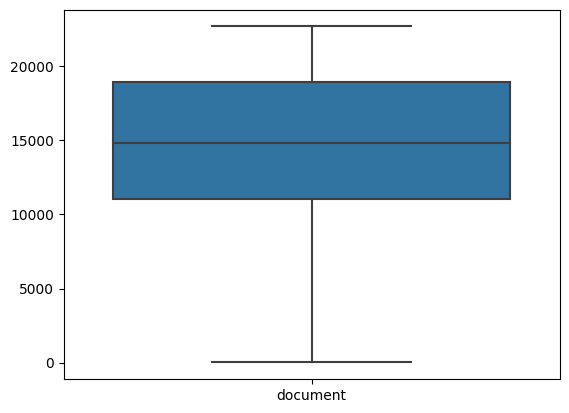

In [26]:
sns.boxplot(combined)

<Axes: >

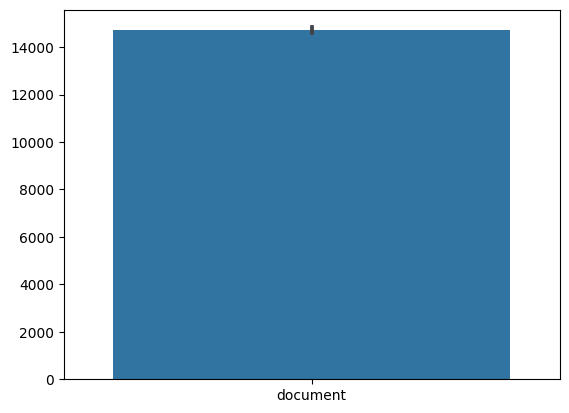

In [27]:
sns.barplot(combined)

<Axes: >

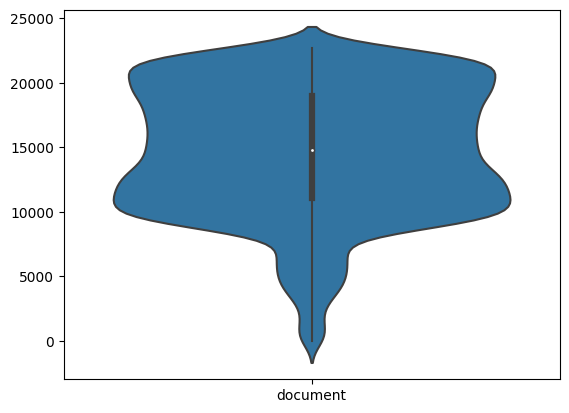

In [28]:
sns.violinplot(combined)

<Axes: >

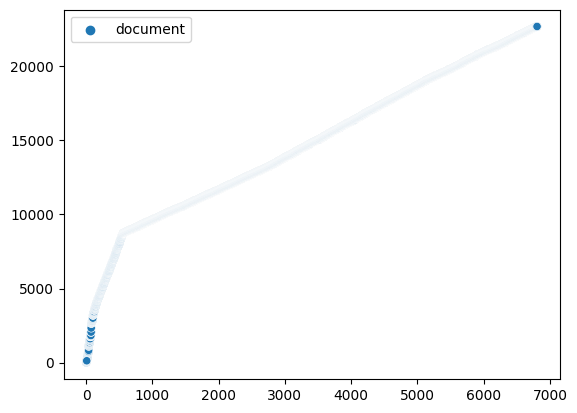

In [29]:
sns.scatterplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Density'>

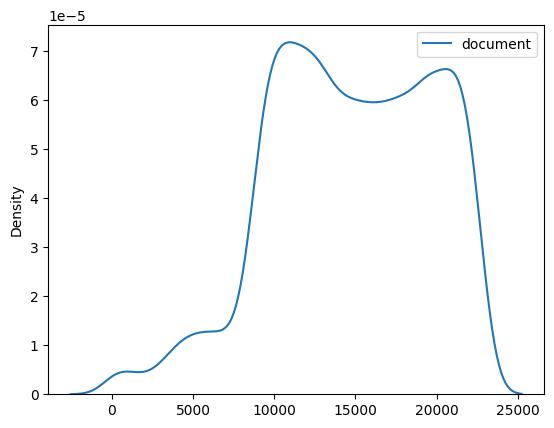

In [30]:
sns.kdeplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

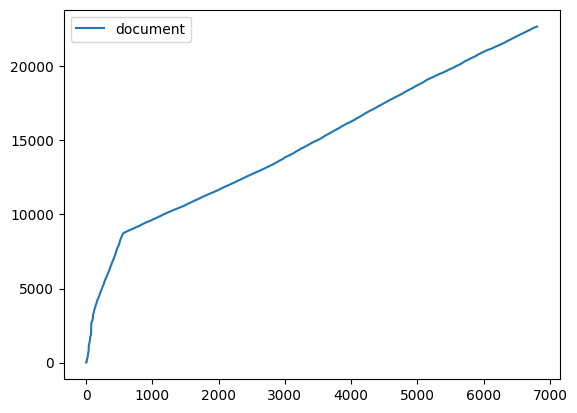

In [31]:
sns.lineplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


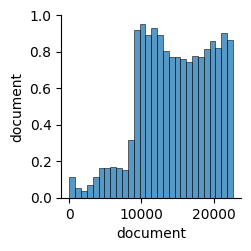

In [33]:
sns.pairplot(combined)

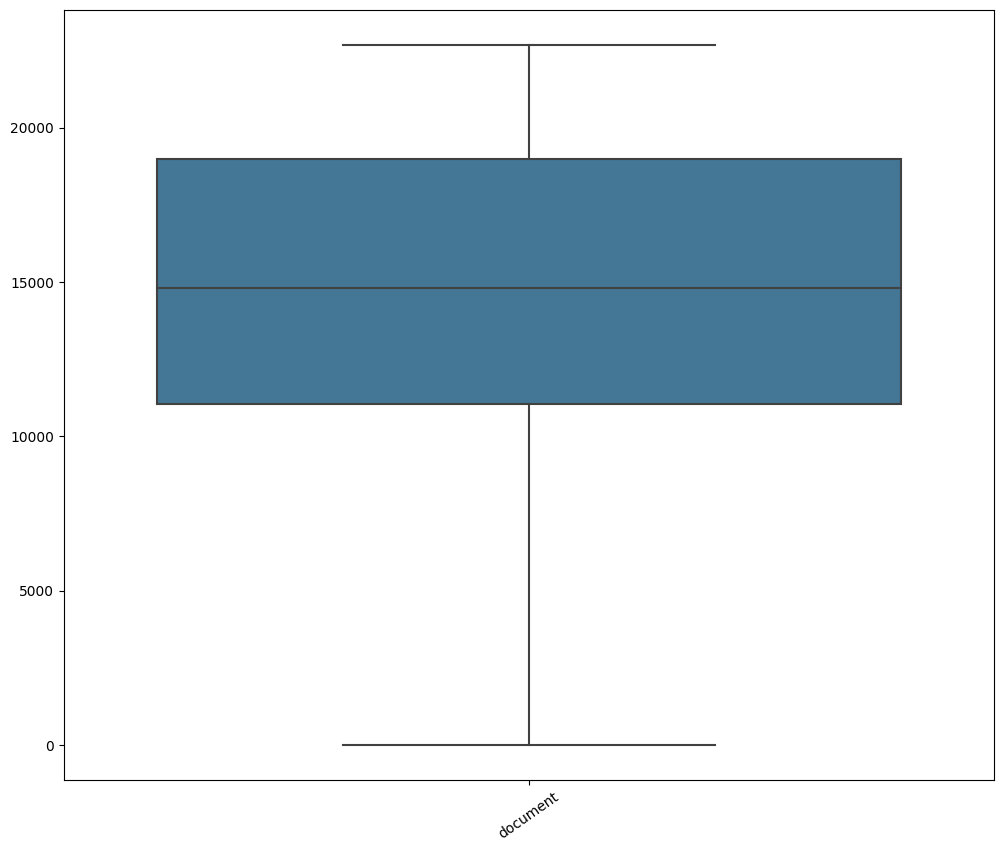

In [38]:
plt.figure(figsize=(12,10))
sns.boxplot(data=combined,palette='mako');
plt.xticks(rotation=35);

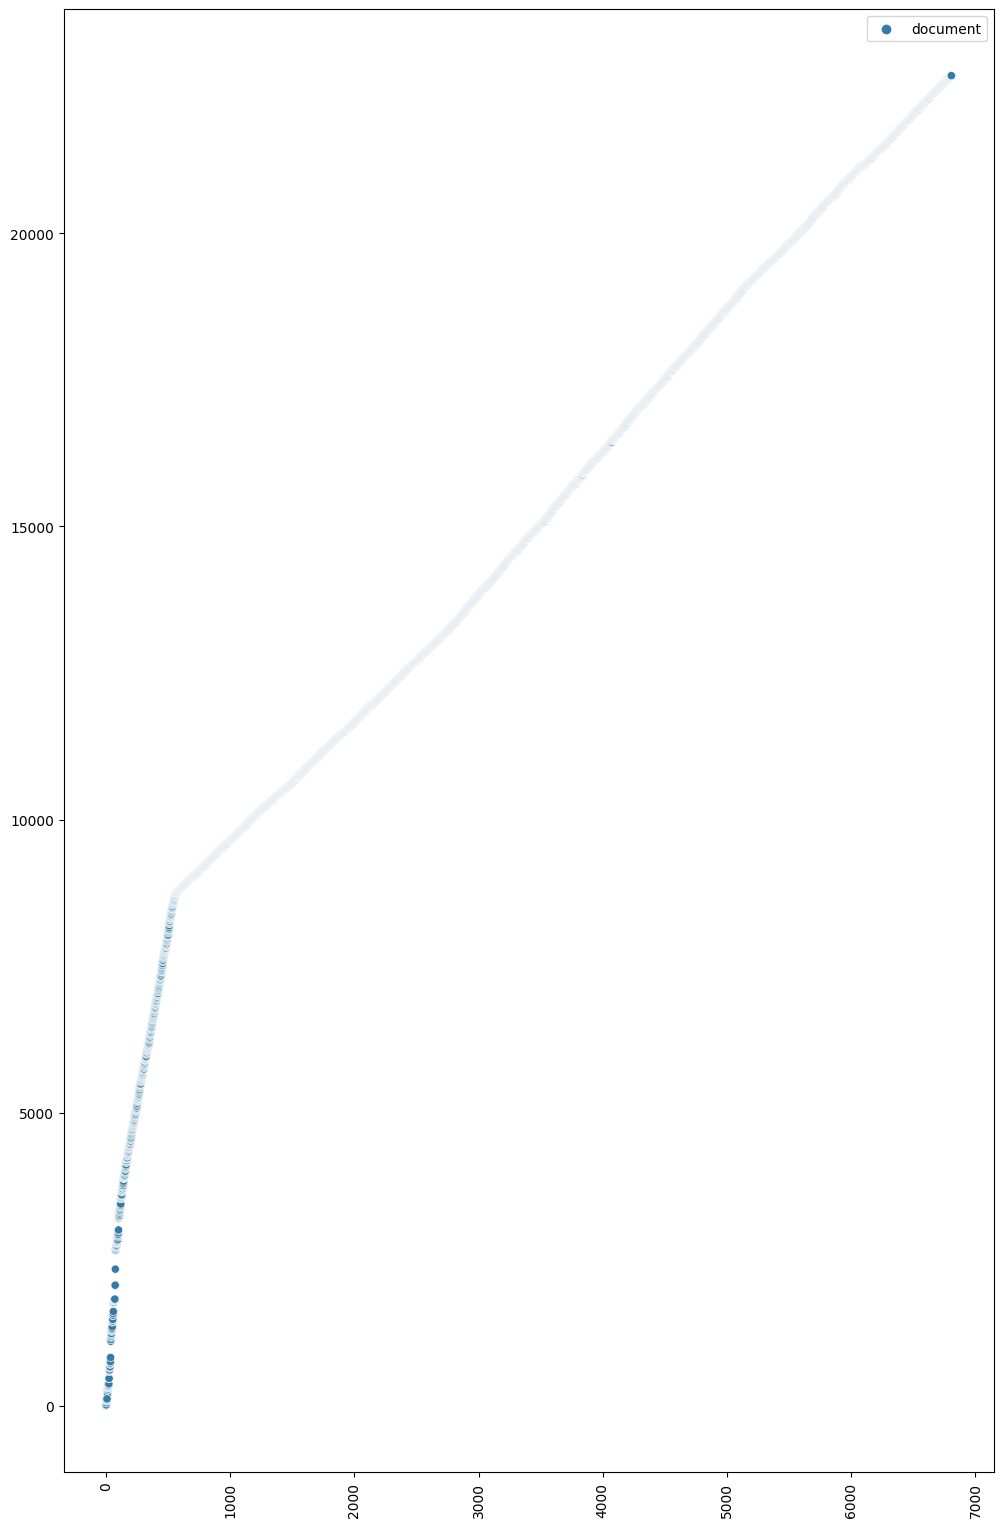

In [39]:
plt.figure(figsize=(12,19))
sns.scatterplot(data=combined,palette='mako')
plt.xticks(rotation=90);

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


(array([-5000.,     0.,  5000., 10000., 15000., 20000., 25000., 30000.]),
 [Text(-5000.0, 0, '−5000'),
  Text(0.0, 0, '0'),
  Text(5000.0, 0, '5000'),
  Text(10000.0, 0, '10000'),
  Text(15000.0, 0, '15000'),
  Text(20000.0, 0, '20000'),
  Text(25000.0, 0, '25000'),
  Text(30000.0, 0, '30000')])

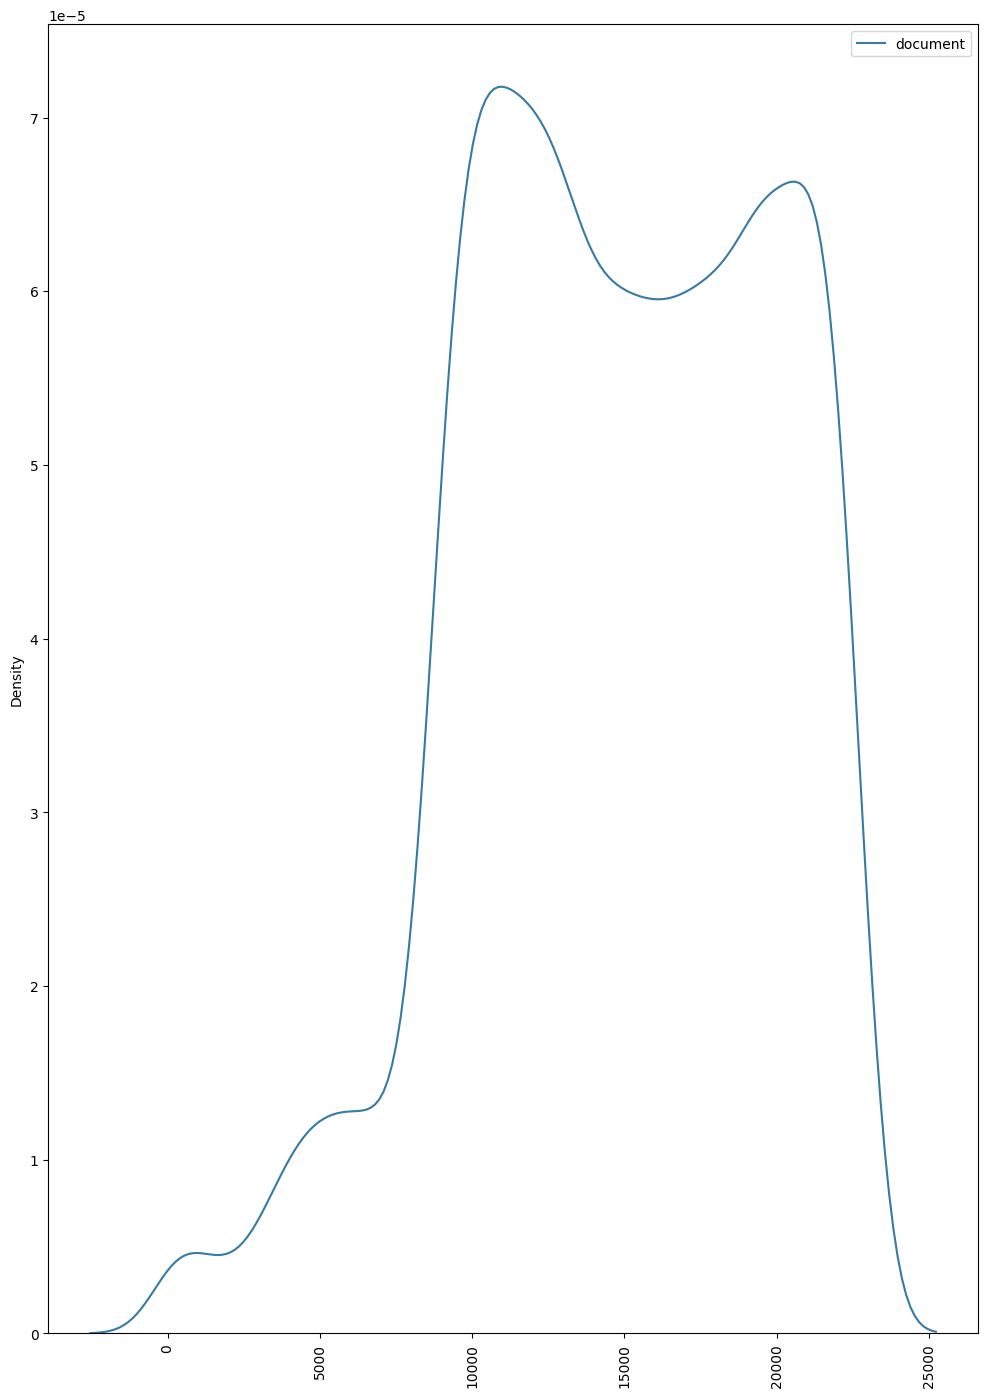

In [40]:
plt.figure(figsize=(12,17))
sns.kdeplot(data=combined,palette='mako')
plt.xticks(rotation=90)

full_text


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


/n


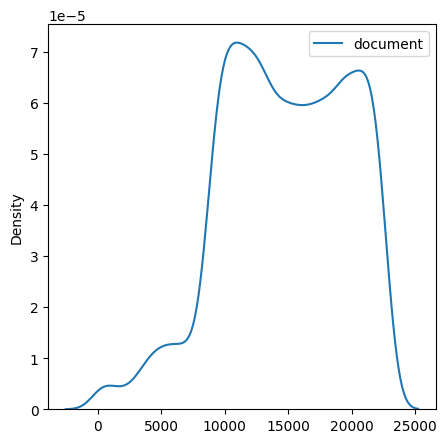

tokens
/n

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


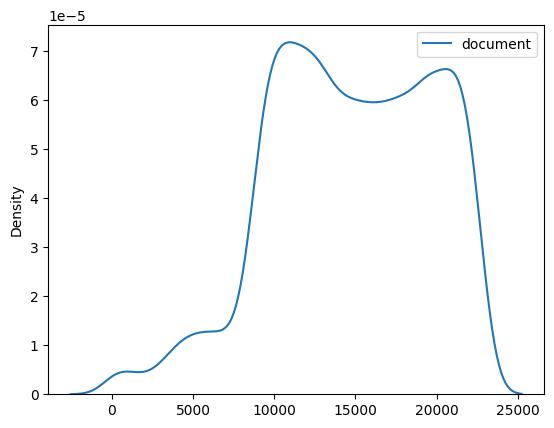

trailing_whitespace
/n


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


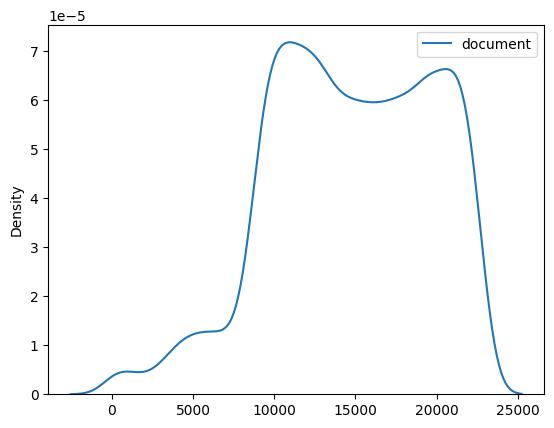

labels
/n


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


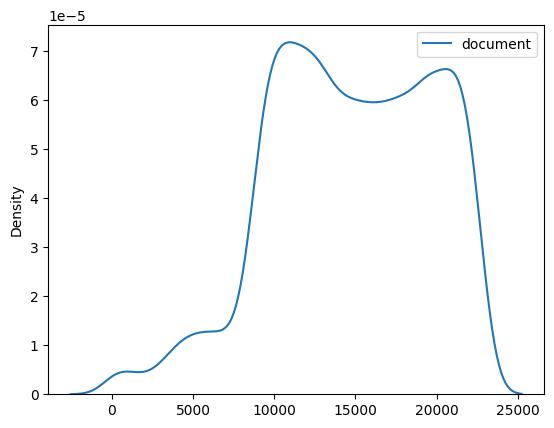

In [44]:
plt.figure(figsize=(5,5))
for i in cat_cols:
    print(i)
    sns.kdeplot(combined)
    print('/n')
    plt.show()

document
/n


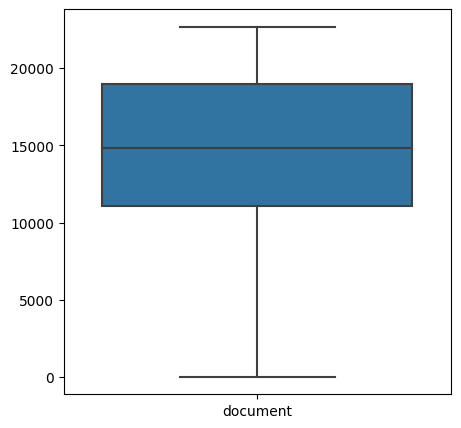

In [47]:
plt.figure(figsize=(5,5))
for i in num_cols:
    print(i)
    sns.boxplot(combined)
    print('/n')
    plt.show()

In [48]:
combined.head()

,document,full_text,tokens,trailing_whitespace,labels
0,7,Design Thinking for innovation reflexion-Avril...,"[Design, Thinking, for, innovation, reflexion,...","[True, True, True, True, False, False, True, F...","[O, O, O, O, O, O, O, O, O, B-NAME_STUDENT, I-..."
1,10,Diego Estrada\n\nDesign Thinking Assignment\n\...,"[Diego, Estrada, \n\n, Design, Thinking, Assig...","[True, False, False, True, True, False, False,...","[B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O, O..."
2,16,Reporting process\n\nby Gilberto Gamboa\n\nCha...,"[Reporting, process, \n\n, by, Gilberto, Gambo...","[True, False, False, True, True, False, False,...","[O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O..."
3,20,Design Thinking for Innovation\n\nSindy Samaca...,"[Design, Thinking, for, Innovation, \n\n, Sind...","[True, True, True, False, False, True, False, ...","[O, O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT..."
4,56,Assignment: Visualization Reflection Submitt...,"[Assignment, :, , Visualization, , Reflecti...","[False, False, False, False, False, False, Fal...","[O, O, O, O, O, O, O, O, O, O, O, O, B-NAME_ST..."


In [49]:
combined.value_counts('full_text')

full_text
Silvia Villalobos\n\nChallenge:\n\nThere is a company which provides financial advisory to customers either in person or virtual.  Lately organisation climate has been seen decayed as result of arguments, hassles and the  lack of fraternity and cooperation among the campaign workers. The aim is improving  climate organisation to transmit unity and trust to our customer.\n\nSelection:\n\nStorytelling is the first tool selected, because this tool allows to connect with the audience,  to make understandable the message, and to transmit emotions. Campaign workers would  feel identified and understand the importance of tolerance and empathy.\n\nApplication and insight:\n\nMany stories were told in various sections. Stories from previous experiences, fictional  stories, and stories told by participants created a different atmosphere due to participants  started to produce deeper relationships among them and recognize the importance of being  empathic. An important result was that m

In [8]:
combined.head()

,document,full_text,tokens,trailing_whitespace,labels
0,7,Design Thinking for innovation reflexion-Avril...,"[Design, Thinking, for, innovation, reflexion,...","[True, True, True, True, False, False, True, F...","[O, O, O, O, O, O, O, O, O, B-NAME_STUDENT, I-..."
1,10,Diego Estrada\n\nDesign Thinking Assignment\n\...,"[Diego, Estrada, \n\n, Design, Thinking, Assig...","[True, False, False, True, True, False, False,...","[B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O, O..."
2,16,Reporting process\n\nby Gilberto Gamboa\n\nCha...,"[Reporting, process, \n\n, by, Gilberto, Gambo...","[True, False, False, True, True, False, False,...","[O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O..."
3,20,Design Thinking for Innovation\n\nSindy Samaca...,"[Design, Thinking, for, Innovation, \n\n, Sind...","[True, True, True, False, False, True, False, ...","[O, O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT..."
4,56,Assignment: Visualization Reflection Submitt...,"[Assignment, :, , Visualization, , Reflecti...","[False, False, False, False, False, False, Fal...","[O, O, O, O, O, O, O, O, O, O, O, O, B-NAME_ST..."


In [9]:
x = combined[['document']]

In [10]:
y = [['document']]

In [15]:
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm

In [16]:
import warnings
warnings.filterwarnings('ignore')

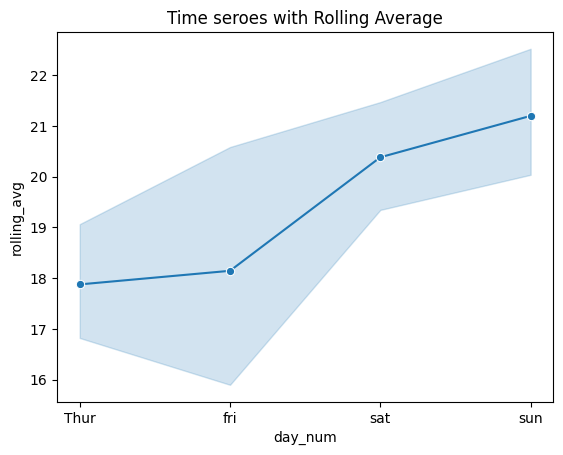

In [19]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill']. rolling(window=3).mean()

sns.lineplot(x='day_num',y='rolling_avg',data=df_tips,marker='o')
plt.xticks(ticks=[0,1,2,3], labels=['Thur','fri','sat','sun'])
plt.title("Time seroes with Rolling Average")
plt.show()